In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

sys.path.append(str(PROJECT_ROOT / "scripts"))

import torch
import numpy as np
import pandas as pd

from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
)

from src.data import (
    load_representation,
    load_target,
    load_split,
    apply_standardization,
)

from src.evaluation import (
    load_model_from_checkpoint,
    predict_array,
)

from src.utils import get_device

In [5]:
from pathlib import Path
import pandas as pd
import numpy as np

MODEL_ROOT = Path(
    "/work3/s252608/DL_project/data/output/model"
)

rows = []

for metrics_file in MODEL_ROOT.rglob("metrics_seed*.csv"):

    parts = metrics_file.parts

    representation = parts[-4]
    target_mode = parts[-3]
    model_type = parts[-2]

    df = pd.read_csv(metrics_file)

    df["representation"] = representation
    df["target_mode"] = target_mode
    df["model_type"] = model_type

    rows.append(df)

results = pd.concat(rows, ignore_index=True)

# Keep only test split
results = results.query("split == 'test'").copy()

# Representation order
repr_order = [
    "raw",
    "pca",
    "bulkformer",
    "vae_beta0p1",
    "vae_beta0p3",
    "vae_beta0p5",
    "vae_beta1p0",
]

results["representation"] = pd.Categorical(
    results["representation"],
    categories=repr_order,
    ordered=True,
)

# Pretty names
pretty_repr = {
    "raw": "Raw",
    "pca": "PCA",
    "bulkformer": "BulkFormer",
    "vae_beta0p1": "VAE β=0.1",
    "vae_beta0p3": "VAE β=0.3",
    "vae_beta0p5": "VAE β=0.5",
    "vae_beta1p0": "VAE β=1.0",
}

results["representation"] = (
    results["representation"]
    .astype(str)
    .replace(pretty_repr)
)

# ---------------------------
# MAIN TABLE
# ---------------------------

main_table = (
    results.pivot_table(
        index="representation",
        columns="model_type",
        values=["pearson_global", "r2"],
    )
)

main_table.columns = [
    f"{metric.replace('_global','').capitalize()} ({model.upper()})"
    for metric, model in main_table.columns
]

main_table = main_table.round(3)

display(main_table)

# ---------------------------
# SUPPORTING TABLE
# ---------------------------

support_table = (
    results.pivot_table(
        index="representation",
        columns="model_type",
        values=["spearman_global", "rmse", "mae"],
    )
)

support_table.columns = [
    f"{metric.replace('_global','').capitalize()} ({model.upper()})"
    for metric, model in support_table.columns
]

support_table = support_table.round(3)

display(support_table)

,Pearson (GAUSSIAN),Pearson (MSE),Pearson (NB),R2 (GAUSSIAN),R2 (MSE),R2 (NB)
representation,,,,,,
BulkFormer,0.872,0.880,0.241,0.758,0.775,0.048
PCA,0.886,0.899,0.219,0.783,0.807,0.041
Raw,0.890,0.903,0.227,0.790,0.815,0.045
VAE β=0.1,0.863,0.870,0.222,0.745,0.757,0.041
VAE β=0.3,0.871,0.878,0.228,0.756,0.770,0.043
VAE β=0.5,0.860,0.866,0.223,0.740,0.749,0.041
VAE β=1.0,0.866,0.872,0.221,0.748,0.760,0.041


,Mae (GAUSSIAN),Mae (MSE),Mae (NB),Rmse (GAUSSIAN),Rmse (MSE),Rmse (NB),Spearman (GAUSSIAN),Spearman (MSE),Spearman (NB)
representation,,,,,,,,,
BulkFormer,0.556,0.552,154.719,0.859,0.828,2647.339,0.786,0.790,0.667
PCA,0.518,0.509,162.169,0.812,0.766,2658.421,0.797,0.806,0.655
Raw,0.513,0.501,160.504,0.800,0.750,2652.206,0.802,0.811,0.663
VAE β=0.1,0.577,0.572,158.171,0.881,0.861,2657.911,0.776,0.778,0.663
VAE β=0.3,0.560,0.555,158.865,0.862,0.836,2655.102,0.783,0.786,0.663
VAE β=0.5,0.584,0.581,157.805,0.890,0.873,2657.990,0.772,0.774,0.661
VAE β=1.0,0.571,0.568,159.724,0.875,0.854,2657.747,0.779,0.780,0.659


In [4]:
pearson_table = (
    results
    .pivot(
        index="representation",
        columns="model_type",
        values="pearson_global",
    )
    .sort_index()
)

pearson_table

model_type,gaussian,mse,nb
representation,,,
bulkformer,0.871766,0.880434,0.241171
pca,0.885620,0.898614,0.218859
raw,0.889868,0.903298,0.226827
vae_beta0p1,0.863390,0.869838,0.222461
vae_beta0p3,0.870588,0.877545,0.227727
vae_beta0p5,0.860401,0.865562,0.222804
vae_beta1p0,0.865664,0.871912,0.221461


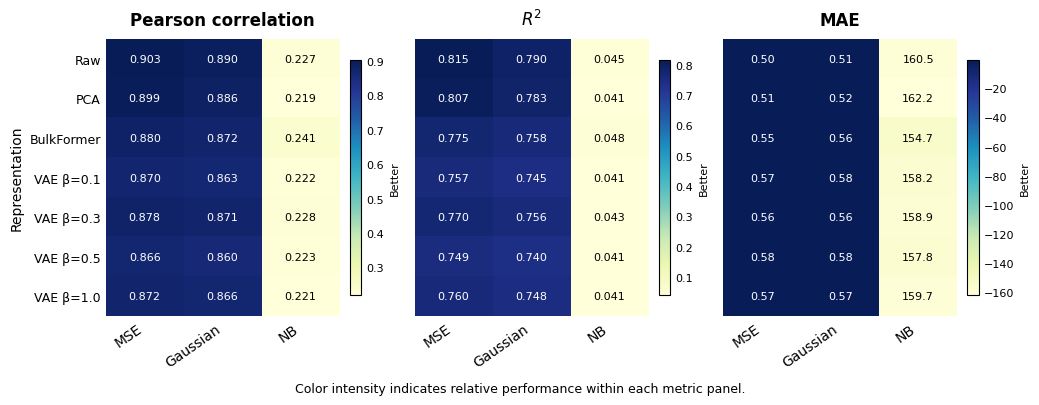

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize

# -------------------------
# Data
# -------------------------
data = {
    "representation": [
        "Raw", "PCA", "BulkFormer",
        "VAE β=0.1", "VAE β=0.3",
        "VAE β=0.5", "VAE β=1.0"
    ],

    "Pearson (MSE)": [0.903, 0.899, 0.880, 0.870, 0.878, 0.866, 0.872],
    "Pearson (Gaussian)": [0.890, 0.886, 0.872, 0.863, 0.871, 0.860, 0.866],
    "Pearson (NB)": [0.227, 0.219, 0.241, 0.222, 0.228, 0.223, 0.221],

    "R² (MSE)": [0.815, 0.807, 0.775, 0.757, 0.770, 0.749, 0.760],
    "R² (Gaussian)": [0.790, 0.783, 0.758, 0.745, 0.756, 0.740, 0.748],
    "R² (NB)": [0.045, 0.041, 0.048, 0.041, 0.043, 0.041, 0.041],

    "MAE (MSE)": [0.501, 0.509, 0.552, 0.572, 0.555, 0.581, 0.568],
    "MAE (Gaussian)": [0.513, 0.518, 0.556, 0.577, 0.560, 0.584, 0.571],
    "MAE (NB)": [160.5, 162.2, 154.7, 158.2, 158.9, 157.8, 159.7]
}

df = pd.DataFrame(data).set_index("representation")

panels = [
    ("Pearson correlation", ["Pearson (MSE)", "Pearson (Gaussian)", "Pearson (NB)"], "higher"),
    (r"$R^2$", ["R² (MSE)", "R² (Gaussian)", "R² (NB)"], "higher"),
    ("MAE", ["MAE (MSE)", "MAE (Gaussian)", "MAE (NB)"], "lower"),
]

# -------------------------
# Plot
# -------------------------
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.9), sharey=True)

for ax, (title, cols, direction) in zip(axes, panels):
    values = df[cols].values.astype(float)

    # Convert all metrics so that larger score = better performance.
    # This makes the color meaning consistent across panels.
    if direction == "lower":
        score = -values
    else:
        score = values

    norm = Normalize(vmin=score.min(), vmax=score.max())

    im = ax.imshow(
        score,
        cmap="YlGnBu",
        aspect="auto",
        norm=norm
    )

    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)

    ax.set_xticks(np.arange(3))
    ax.set_xticklabels(["MSE", "Gaussian", "NB"], rotation=35, ha="right")

    ax.set_yticks(np.arange(len(df.index)))
    ax.set_yticklabels(df.index, fontsize=9)

    ax.tick_params(axis="both", length=0)

    # Cell annotations
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            value = values[i, j]

            if title == "MAE":
                label = f"{value:.2f}" if value < 10 else f"{value:.1f}"
            else:
                label = f"{value:.3f}"

            scaled = norm(score[i, j])

            # Dark cells need white text; light cells need black text.
            text_color = "white" if scaled > 0.55 else "black"

            ax.text(
                j,
                i,
                label,
                ha="center",
                va="center",
                fontsize=8,
                color=text_color
            )

    for spine in ax.spines.values():
        spine.set_visible(False)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=8, length=0)
    cbar.set_label("Better", fontsize=8)

axes[0].set_ylabel("Representation", fontsize=10)

fig.text(
    0.5,
    -0.02,
    "Color intensity indicates relative performance within each metric panel.",
    ha="center",
    fontsize=9
)

plt.tight_layout()
plt.savefig(
    "performance_heatmap_paper_readable.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [4]:
import anndata as ad
import numpy as np
from scipy.sparse import issparse

path = "/work3/s252608/DL_project/data/processed/bulk_normalized_y_target_CPM.h5ad"

adata = ad.read_h5ad(path, backed="r")
raw = adata.layers["raw_counts"]

lib = np.asarray(raw.sum(axis=1)).ravel()

print(lib.min(), np.median(lib), lib.max())
print(np.percentile(lib, [0, 1, 5, 50, 95, 99, 100]))

adata.file.close()

83 4004396.5 75288878
[8.30000000e+01 7.95057790e+05 1.47577655e+06 4.00439650e+06
 1.07263750e+07 1.79733240e+07 7.52888780e+07]


In [5]:
import numpy as np

bad_idx = np.where(lib < 10000)[0]   # threshold razonable inicial
print(len(bad_idx))

for i in bad_idx[:20]:
    print(i, lib[i], adata.obs_names[i])

1
5560 83 GSM4067384


In [6]:
for t in [100, 1_000, 10_000, 100_000, 500_000]:
    print(t, (lib < t).sum())

100 1
1000 1
10000 1
100000 14
500000 87


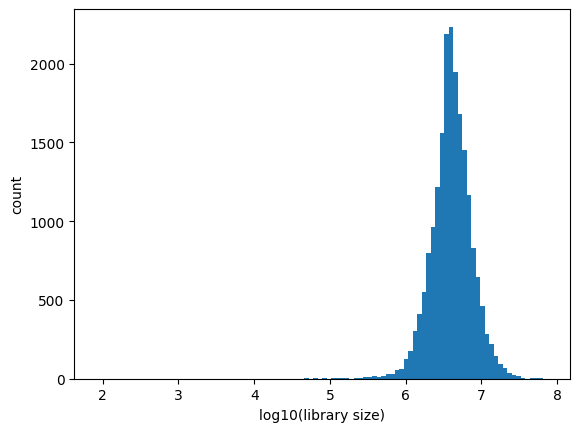

In [7]:
import matplotlib.pyplot as plt

plt.hist(np.log10(lib + 1), bins=100)
plt.xlabel("log10(library size)")
plt.ylabel("count")
plt.show()

In [9]:
i = 5560

print("obs_name:", adata.obs_names[i])
print("library size:", lib[i])

print(adata.obs.iloc[i])

obs_name: GSM4067384
library size: 83
geo_accession                                                         GSM4067384
series_id                                                              GSE137127
characteristics_ch1                     diagnosis: Control,nrxn1 status: Control
extract_protocol_ch1           Trizol was added to cells while in the plate, ...
source_name_ch1                                          adult post-mortem dlPFC
title                                                                    Adult_1
contact_city                                                         Minneapolis
contact_country                                                              USA
contact_institute                         University of Minnesota Medical School
instrument_model                                                  Illumina MiSeq
library_source                                                    transcriptomic
organism_ch1                                                        Hom

In [10]:
print(adata.layers.keys())

KeysView(Layers with keys: raw_counts)


In [11]:
row = raw[5560]

if issparse(row):
    row = row.toarray().ravel()

print(row.sum())
print((row > 0).sum())
print(row.max())
print(np.sort(row)[-20:])

83
41
8
[1 1 1 2 2 2 2 2 2 2 3 3 3 3 3 4 5 6 7 8]


In [12]:
i = 5560

x = adata.X[i]
if issparse(x):
    x = x.toarray().ravel()

print("X sum:", x.sum())
print("X nonzero:", (x > 0).sum())
print("X max:", x.max())

print("obs total_counts:", adata.obs.iloc[i]["total_counts"])
print("obs n_genes:", adata.obs.iloc[i]["n_genes"])

X sum: 404.4238972552841
X nonzero: 41
X max: 11.476121866793692
obs total_counts: 28340728
obs n_genes: 433


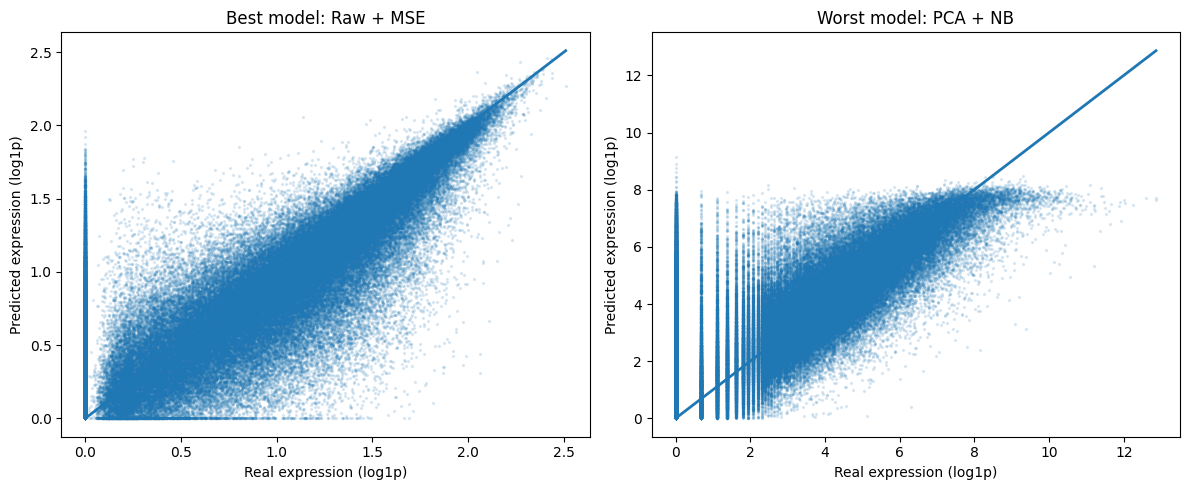

In [7]:
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
from pathlib import Path

best_model = Path(
    "/work3/s252608/DL_project/data/output/model/raw/absolute/mse/preds_seed1.h5ad"
)

worst_model = Path(
    "/work3/s252608/DL_project/data/output/model/pca/absolute/nb/preds_seed1.h5ad"
)


def load_true_pred(path, log1p=True, max_points=200_000, seed=42):
    adata = ad.read_h5ad(path, backed="r")

    y_pred = np.asarray(adata.X[:]).ravel()
    y_true = np.asarray(adata.layers["true"][:]).ravel()

    adata.file.close()

    if log1p:
        y_true = np.log1p(np.clip(y_true, 0, None))
        y_pred = np.log1p(np.clip(y_pred, 0, None))

    rng = np.random.default_rng(seed)

    if y_true.size > max_points:
        idx = rng.choice(
            y_true.size,
            size=max_points,
            replace=False,
        )
        y_true = y_true[idx]
        y_pred = y_pred[idx]

    return y_true, y_pred


def plot_comparison(best_path, worst_path):

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    configs = [
        (best_path, "Best model: Raw + MSE"),
        (worst_path, "Worst model: PCA + NB"),
    ]

    for ax, (path, title) in zip(axes, configs):

        y_true, y_pred = load_true_pred(
            path,
            log1p=True,
        )

        ax.scatter(
            y_true,
            y_pred,
            s=2,
            alpha=0.12,
        )

        min_val = min(y_true.min(), y_pred.min())
        max_val = max(y_true.max(), y_pred.max())

        ax.plot(
            [min_val, max_val],
            [min_val, max_val],
            linewidth=2,
        )

        ax.set_xlabel("Real expression (log1p)")
        ax.set_ylabel("Predicted expression (log1p)")
        ax.set_title(title)

    plt.tight_layout()
    plt.show()


plot_comparison(best_model, worst_model)

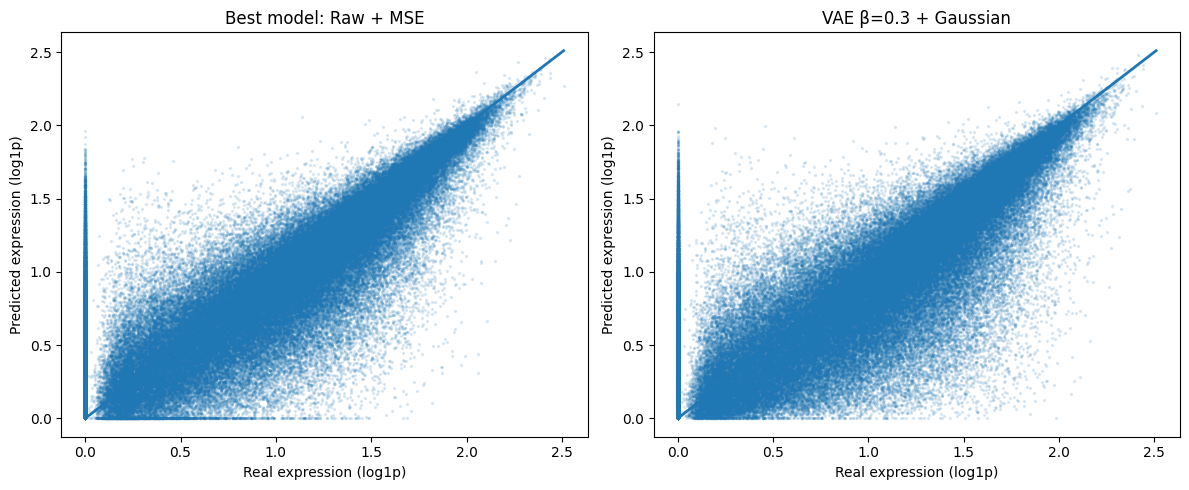

In [8]:
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
from pathlib import Path

best_model = Path(
    "/work3/s252608/DL_project/data/output/model/raw/absolute/mse/preds_seed1.h5ad"
)

vae_gaussian_b03 = Path(
    "/work3/s252608/DL_project/data/output/model/vae_beta0p3/absolute/gaussian/preds_seed1.h5ad"
)


def load_true_pred(path, log1p=True, max_points=200_000, seed=42):
    adata = ad.read_h5ad(path, backed="r")

    y_pred = np.asarray(adata.X[:]).ravel()
    y_true = np.asarray(adata.layers["true"][:]).ravel()

    adata.file.close()

    if log1p:
        y_true = np.log1p(np.clip(y_true, 0, None))
        y_pred = np.log1p(np.clip(y_pred, 0, None))

    rng = np.random.default_rng(seed)

    if y_true.size > max_points:
        idx = rng.choice(
            y_true.size,
            size=max_points,
            replace=False,
        )
        y_true = y_true[idx]
        y_pred = y_pred[idx]

    return y_true, y_pred


def plot_comparison(model_a, model_b):

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    configs = [
        (model_a, "Best model: Raw + MSE"),
        (model_b, "VAE β=0.3 + Gaussian"),
    ]

    for ax, (path, title) in zip(axes, configs):

        y_true, y_pred = load_true_pred(
            path,
            log1p=True,
        )

        ax.scatter(
            y_true,
            y_pred,
            s=2,
            alpha=0.12,
        )

        min_val = min(y_true.min(), y_pred.min())
        max_val = max(y_true.max(), y_pred.max())

        ax.plot(
            [min_val, max_val],
            [min_val, max_val],
            linewidth=2,
        )

        ax.set_xlabel("Real expression (log1p)")
        ax.set_ylabel("Predicted expression (log1p)")
        ax.set_title(title)

    plt.tight_layout()
    plt.show()


plot_comparison(best_model, vae_gaussian_b03)

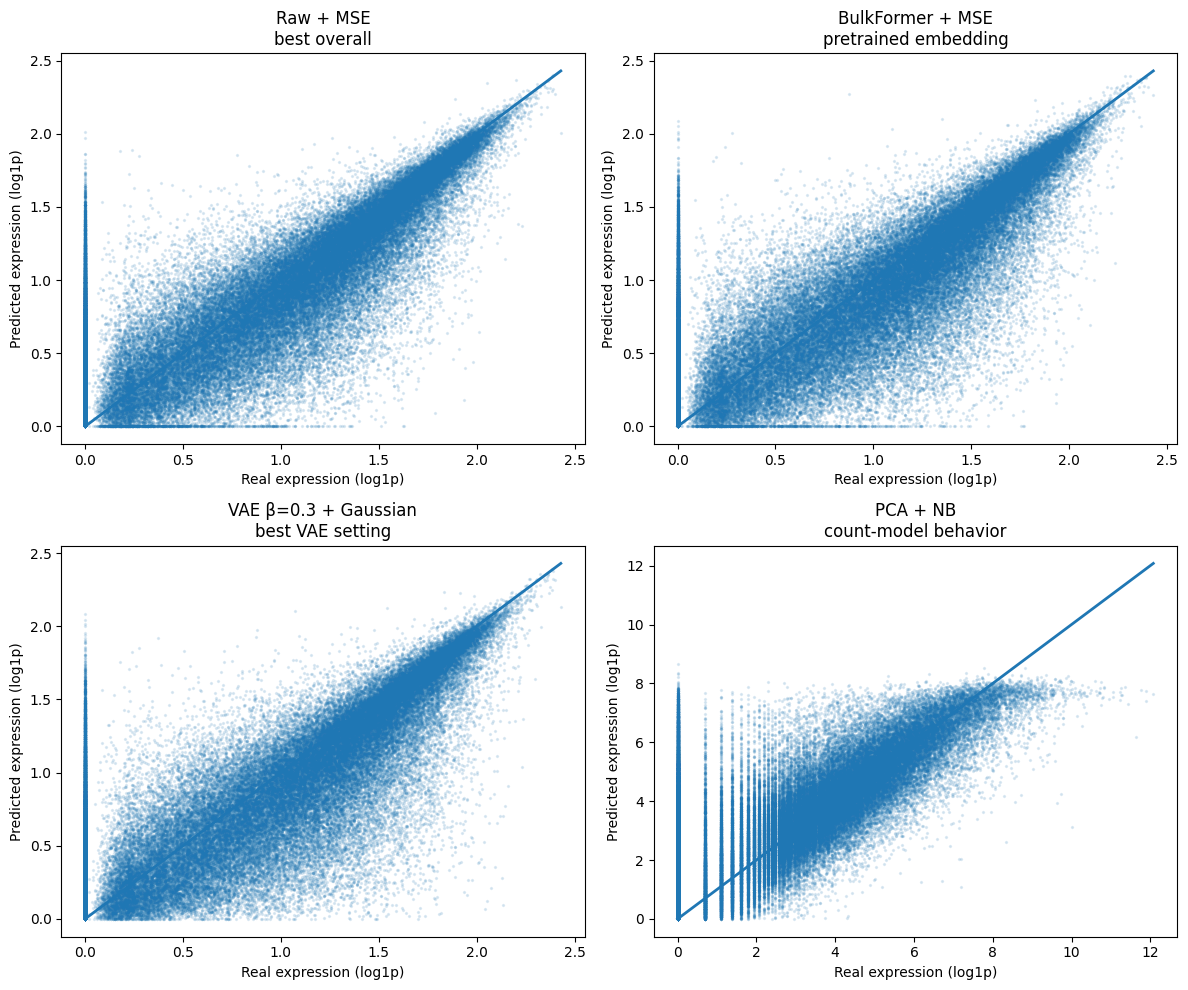

In [9]:
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
from pathlib import Path

models = [
    (
        "Raw + MSE\nbest overall",
        Path("/work3/s252608/DL_project/data/output/model/raw/absolute/mse/preds_seed1.h5ad"),
    ),
    (
        "BulkFormer + MSE\npretrained embedding",
        Path("/work3/s252608/DL_project/data/output/model/bulkformer/absolute/mse/preds_seed1.h5ad"),
    ),
    (
        "VAE β=0.3 + Gaussian\nbest VAE setting",
        Path("/work3/s252608/DL_project/data/output/model/vae_beta0p3/absolute/gaussian/preds_seed1.h5ad"),
    ),
    (
        "PCA + NB\ncount-model behavior",
        Path("/work3/s252608/DL_project/data/output/model/pca/absolute/nb/preds_seed1.h5ad"),
    ),
]


def load_true_pred(path, log1p=True, max_points=120_000, seed=42):
    adata = ad.read_h5ad(path, backed="r")

    y_pred = np.asarray(adata.X[:]).ravel()
    y_true = np.asarray(adata.layers["true"][:]).ravel()

    adata.file.close()

    if log1p:
        y_true = np.log1p(np.clip(y_true, 0, None))
        y_pred = np.log1p(np.clip(y_pred, 0, None))

    rng = np.random.default_rng(seed)

    if y_true.size > max_points:
        idx = rng.choice(
            y_true.size,
            size=max_points,
            replace=False,
        )
        y_true = y_true[idx]
        y_pred = y_pred[idx]

    return y_true, y_pred


fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, (title, path) in zip(axes, models):

    y_true, y_pred = load_true_pred(
        path,
        log1p=True,
    )

    ax.scatter(
        y_true,
        y_pred,
        s=2,
        alpha=0.12,
    )

    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())

    ax.plot(
        [min_val, max_val],
        [min_val, max_val],
        linewidth=2,
    )

    ax.set_title(title)
    ax.set_xlabel("Real expression (log1p)")
    ax.set_ylabel("Predicted expression (log1p)")

plt.tight_layout()
plt.show()